In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model_no_previous, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-09-11 20:07:43.003660: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-09-11 20:07:43.059402: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-09-11 20:07:43.059435: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-09-11 20:07:43.059461: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-09-11 20:07:43.067370: I tensorflow/core/platform/cpu_feature_g

Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


In [2]:
COHERENCE_LOSS = None
MAIN_LOSS = None
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = None
INTERPOLATION_FRAMES_LOSS = l1_loss
INTERPOLATION_LANDMARKS_LOSS = None

# Dimensions
r = 256
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68
BATCH_SIZE = 25
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 15
N_TESTING_FRAMES = 42000

LAMBDA_MAIN_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = None
LAMBDA_INTERPOLATION_FRAMES_LOSS = 200
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0
#
LAMBDA_MAIN_LOSS = 0
LAMBDA_COHERENCE_LOSS = 0
LAMBDA_LANDMARKS_LOSS = 0
LAMBDA_LANDMARKS_COHERENCE_LOSS = 0
LAMBDA_PERCEPTUAL_LOSS = None
LAMBDA_INTERPOLATION_FRAMES_LOSS = 100
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
OUPUT_PATH  = APP_PATH / 'output'

default_dimension = "mug128"

In [3]:
id_string = f"e_no_previous_b{BATCH_SIZE}_r{r}_"
if MAIN_LOSS:
    id_string += f"f1_{MAIN_LOSS.__name__}_{LAMBDA_MAIN_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'e_no_previous_b25_r256__f6_l1_loss_100'

In [4]:
log_dir=APP_PATH / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

In [5]:
OUTPUT_MEDIA_FOLDER = OUPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

## Load the dataset

In [6]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

In [7]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [8]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2023-09-11 20:07:51.222911: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14028 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


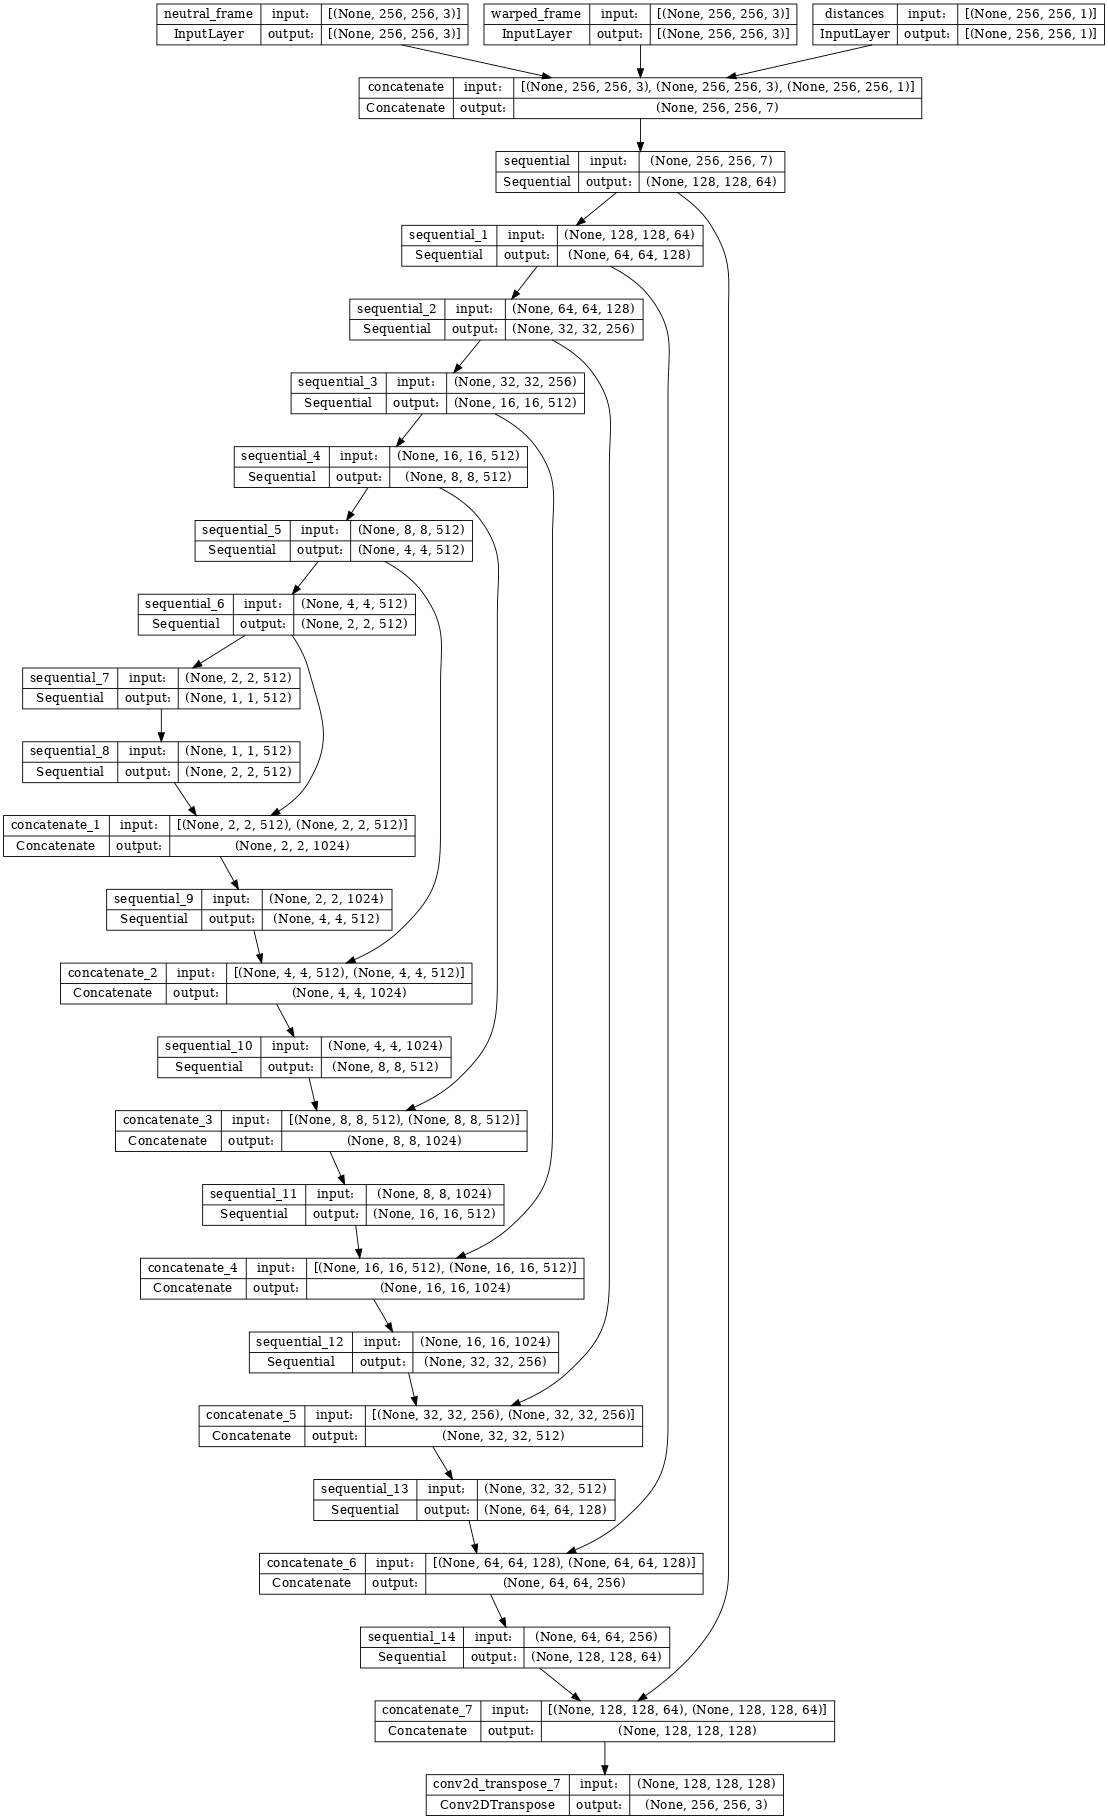

In [9]:
generator = get_generator_model_no_previous(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))

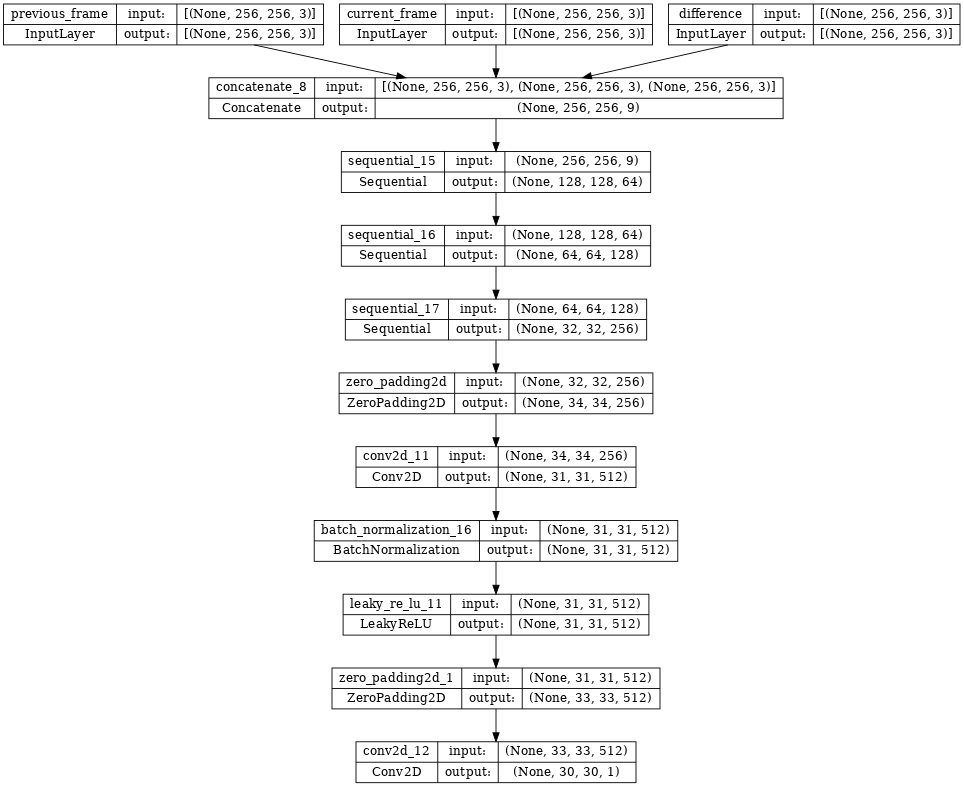

In [10]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))

In [11]:
generator_loss = GeneratorLoss(
    main_loss_function=MAIN_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    coherence_loss_function=COHERENCE_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)
                    

In [12]:
discriminator_loss = DiscriminatorLoss()

In [13]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [14]:
BASE_DIR = OUPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [15]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [16]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss, gen_perceptual_loss, gen_interpolation_frame_loss, gen_interpolation_landmarks_loss = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          if generator_loss.main_loss_function:
            tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=step)
          if generator_loss.coherence_loss_function:
            tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=step)
          if generator_loss.landmarks_loss_function:
            tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=step)
          if generator_loss.landmarks_coherence_loss_function:
            tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=step)
          if generator_loss.lambda_perceptual_loss:
            tf.summary.scalar(f'gen_perceptual_loss', gen_perceptual_loss, step=step)
          if generator_loss.interpolation_frames_loss_function:
            tf.summary.scalar(f'gen_interpolation_frame_loss', gen_interpolation_frame_loss, step=step)
          if generator_loss.interpolation_landmarks_loss_function:
            tf.summary.scalar(f'gen_interpolation_landmarks_loss', gen_interpolation_landmarks_loss, step=step)
          
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [17]:
tf.profiler.experimental.start(str(log_dir))

2023-09-11 20:08:07.843479: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-09-11 20:08:07.843549: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2023-09-11 20:08:07.843626: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1694] Profiler found 1 GPUs


In [18]:
train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


100%|#########9| 3990/4000 [5:25:32<00:27,  2.71s/it]

Input Sequence


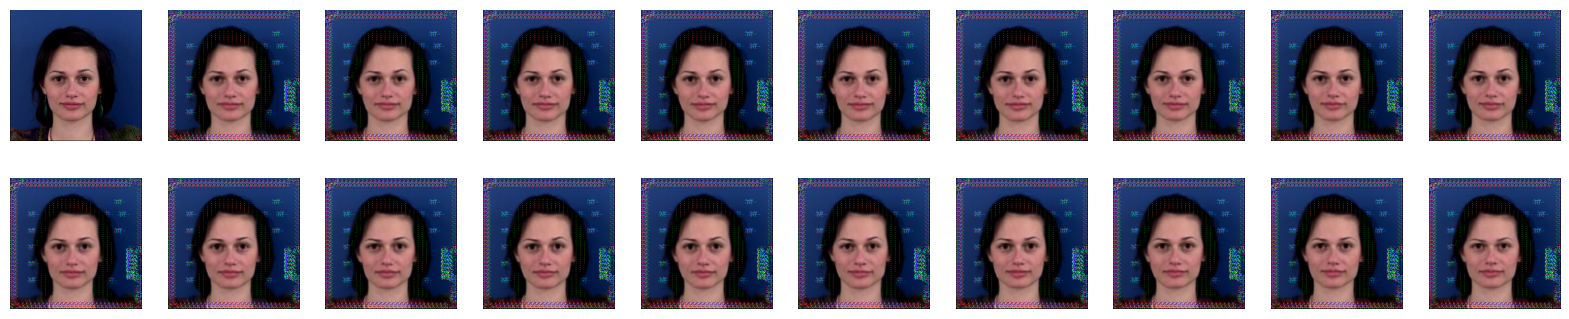

Ground Truth


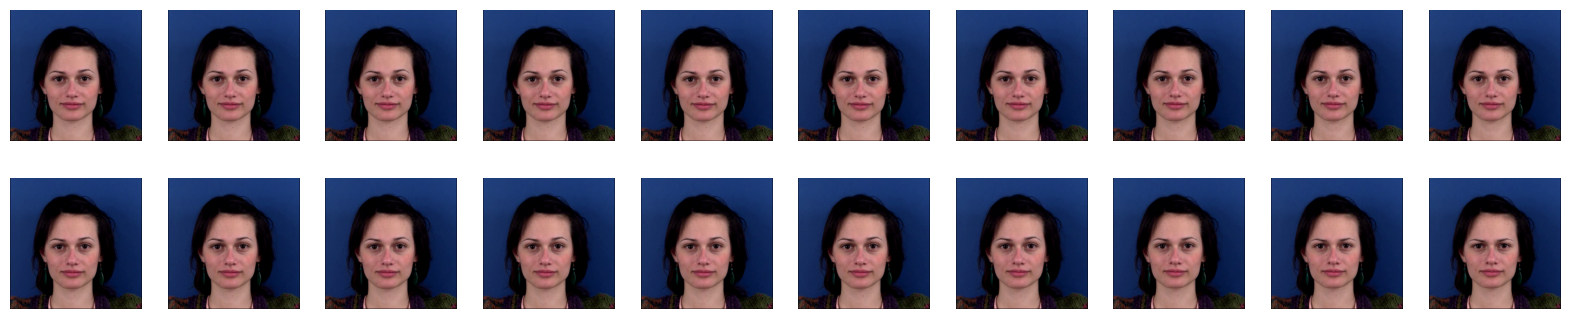

Predicted Sequence


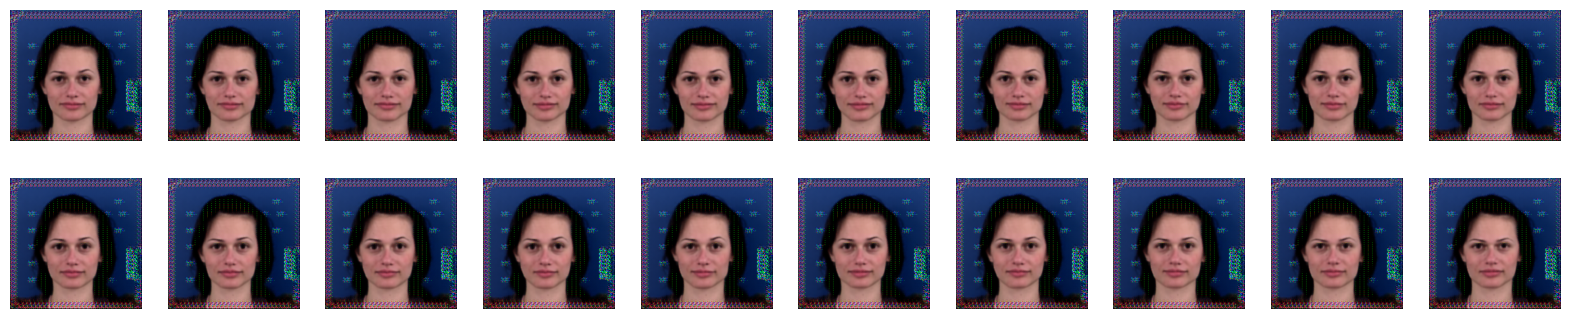

In [19]:
fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [20]:
!ls {checkpoint_dir}

checkpoint		     ckpt-46.data-00000-of-00001
ckpt-1.data-00000-of-00001   ckpt-46.index
ckpt-1.index		     ckpt-47.data-00000-of-00001
ckpt-10.data-00000-of-00001  ckpt-47.index
ckpt-10.index		     ckpt-48.data-00000-of-00001
ckpt-11.data-00000-of-00001  ckpt-48.index
ckpt-11.index		     ckpt-49.data-00000-of-00001
ckpt-12.data-00000-of-00001  ckpt-49.index
ckpt-12.index		     ckpt-5.data-00000-of-00001
ckpt-13.data-00000-of-00001  ckpt-5.index
ckpt-13.index		     ckpt-50.data-00000-of-00001
ckpt-14.data-00000-of-00001  ckpt-50.index
ckpt-14.index		     ckpt-51.data-00000-of-00001
ckpt-15.data-00000-of-00001  ckpt-51.index
ckpt-15.index		     ckpt-52.data-00000-of-00001
ckpt-16.data-00000-of-00001  ckpt-52.index
ckpt-16.index		     ckpt-53.data-00000-of-00001
ckpt-17.data-00000-of-00001  ckpt-53.index
ckpt-17.index		     ckpt-54.data-00000-of-00001
ckpt-18.data-00000-of-00001  ckpt-54.index
ckpt-18.index		     ckpt-55.data-00000-of-00001
ckpt-19.data-00000-of-00001  ckpt-55.index
ckpt-

In [21]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


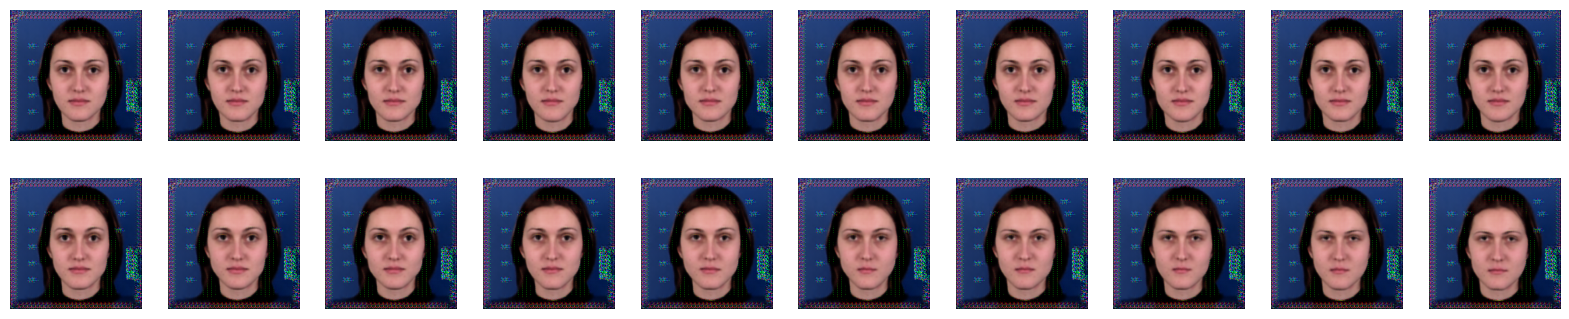

Ground Truth


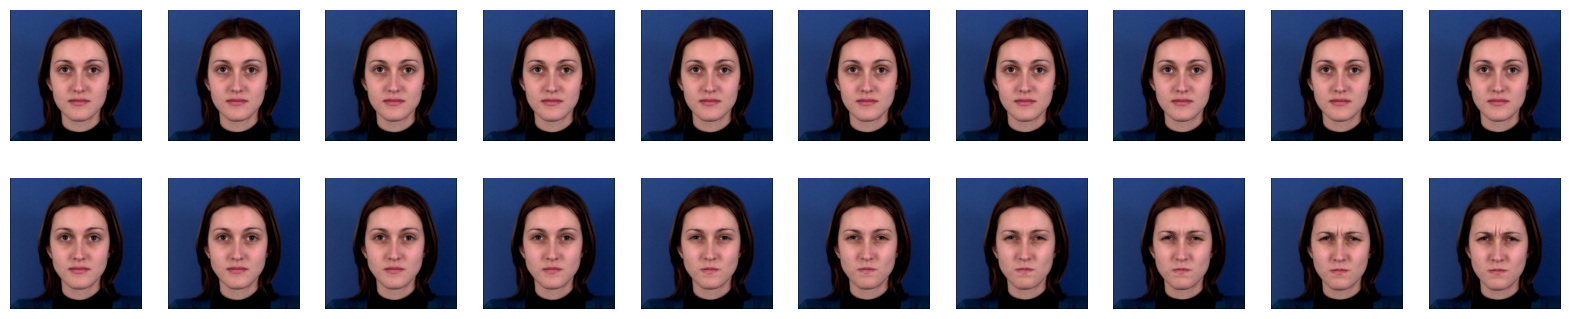

Predicted Sequence


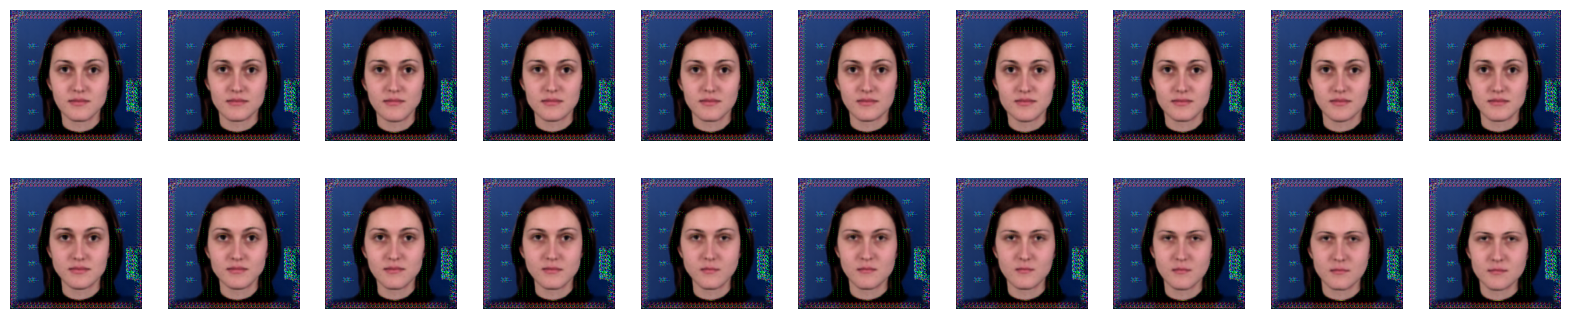

In [22]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  previously_generated, generated_frames, samples_target = test_generator.generate_next_batch()
  clear_output(wait=True)
  plot_results(samples_target, previously_generated, generated_frames)

In [23]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [24]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

In [25]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

scores_path = f"{log_dir}/metrics.csv"
# df = pd.read_csv(scores_path, index_col=0)  
scores = compute_scores()
df = pd.DataFrame(scores)

42075it [1:01:23,  5.16it/s]

SSIM     0.549591
PSNR    16.019182
MSE      0.100540
L1       0.130459
ACD      0.000259
dtype: float64
SSIM    0.040738
PSNR    0.326045
MSE     0.008735
L1      0.015338
ACD     0.000192
dtype: float64


In [26]:
df.to_csv(scores_path)
print(df)

          SSIM       PSNR       MSE        L1       ACD
0     0.570082  16.266115  0.094607  0.120673  0.000434
1     0.535179  16.097263  0.098295  0.133217  0.000380
2     0.537767  16.133774  0.097513  0.131039  0.000179
3     0.580984  16.296267  0.093961  0.119679  0.000082
4     0.592451  16.209675  0.095846  0.127126  0.000484
...        ...        ...       ...       ...       ...
1678  0.550899  16.171137  0.096721  0.127353  0.000108
1679  0.524385  16.157835  0.097019  0.134909  0.000767
1680  0.536708  16.208567  0.095900  0.131498  0.000328
1681  0.573553  16.209946  0.095905  0.119825  0.000203
1682  0.600859  16.275009  0.094436  0.121703  0.000475

[1683 rows x 5 columns]


In [27]:
print(df.mean())

SSIM     0.549591
PSNR    16.019182
MSE      0.100540
L1       0.130459
ACD      0.000259
dtype: float64


In [28]:
print(df.std())

SSIM    0.040738
PSNR    0.326045
MSE     0.008735
L1      0.015338
ACD     0.000192
dtype: float64


# coherence measures

In [29]:
from data_generator import PreprocessedDataGenerator
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)

In [30]:
def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/diff_metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_diff_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

scores_path = f"{log_dir}/diff_metrics.csv"
# df = pd.read_csv(scores_path, index_col=0)  
scores = compute_scores()
df = pd.DataFrame(scores)

42075it [1:02:04,  5.07it/s]

SSIM     0.923233
PSNR    37.662289
MSE      0.001888
L1       0.014181
ACD      0.000245
dtype: float64
SSIM    0.033478
PSNR    2.583344
MSE     0.002851
L1      0.006732
ACD     0.000189
dtype: float64


In [31]:
print(df.mean())

SSIM     0.923233
PSNR    37.662289
MSE      0.001888
L1       0.014181
ACD      0.000245
dtype: float64


In [32]:
print(df.std())

SSIM    0.033478
PSNR    2.583344
MSE     0.002851
L1      0.006732
ACD     0.000189
dtype: float64


In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
for i in range(0,10):
  clear_output(wait=True)
  test_generator.next_plot()